In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Task1

In [2]:
df = pd.read_csv("transactions.csv")
df.head()

,order_id,user_id,amount,date
0,1,101,120.50,2024-01-01
1,2,102,89.99,2024-01-02
2,3,103,45.00,2024-01-02
3,4,104,230.10,2024-01-03
4,5,105,15.75,2024-01-03


In [3]:
print(f"Nan count: \n{df.isna().sum()}")

Nan count: 
order_id    0
user_id     0
amount      2
date        0
dtype: int64


In [4]:
df.describe()

,order_id,user_id,amount
count,25.000000,25.000000,23.000000
mean,13.000000,113.000000,175.394783
std,7.359801,7.359801,233.797434
min,1.000000,101.000000,5.990000
25%,7.000000,107.000000,50.275000
50%,13.000000,113.000000,89.990000
75%,19.000000,119.000000,180.000000
max,25.000000,125.000000,999.990000


In [8]:
nan_arr = np.array(df["amount"])
not_nan_mask = ~np.isnan(nan_arr) 
arr = nan_arr[not_nan_mask]

print(f"Count: {len(arr)}")
print(f"Average: {arr.mean()}")
print(f"{np.median(arr)}")
print(f"{arr.min()}")
print(f"{arr.max()}")
print(f"{np.percentile(arr, 25)}")
print(f"{np.percentile(arr, 50)}")
print(f"{np.percentile(arr, 75)}")

Count: 23
Average: 175.39478260869564
89.99
5.99
999.99
50.275
89.99
180.0


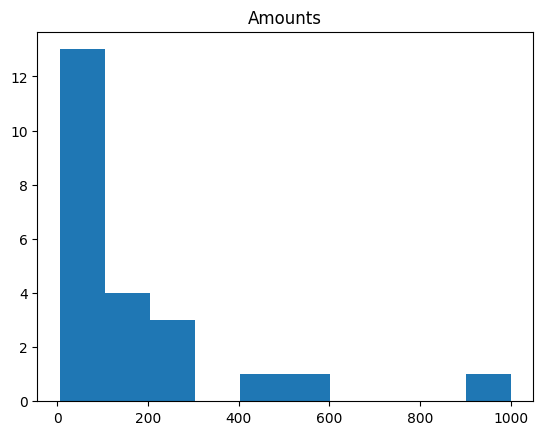

In [9]:
plt.hist(arr)
plt.title("Amounts")
plt.show()

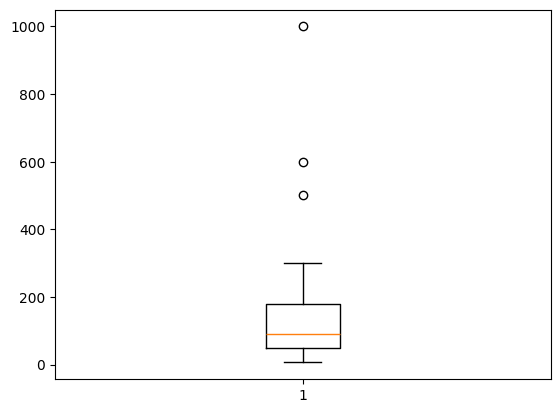

In [10]:
plt.boxplot(arr)
plt.title = "Amounts"
plt.show()

# Task2

In [11]:
arr2_1 = np.array([12, 500, 15, 22, 999, 18, 10])
arr2 = arr2_1.reshape((7, 1))
print(arr2)

[[ 12]
 [500]
 [ 15]
 [ 22]
 [999]
 [ 18]
 [ 10]]


In [18]:
q1 = np.percentile(arr2, 25)
q3 = np.percentile(arr2, 75)
iqr = q3 - q1

print(f"Average: {arr2.mean()}")
print(f"Median: {np.median(arr2)}")
print(f"Std: {arr2.std():.2f}")
print(f"IQR: {iqr}")
print(f"MAD: {stats.median_abs_deviation(arr2)}")
print(f"Skew: {stats.skew(arr2)} \nKurtosis: {stats.kurtosis(arr2)}")

Average: 225.14285714285714
Median: 18.0
Std: 357.46
IQR: 247.5
MAD: [6.]
Skew: [1.36989464] 
Kurtosis: [0.27261777]


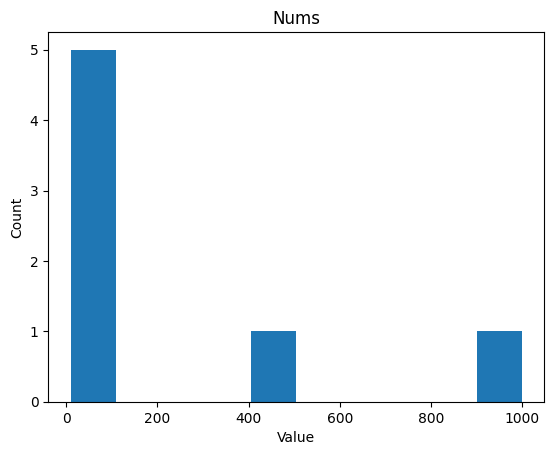

In [16]:
fig, ax = plt.subplots()
ax.hist(arr2)
ax.set_title("Nums")
ax.set_xlabel("Value")
ax.set_ylabel("Count")
plt.show()

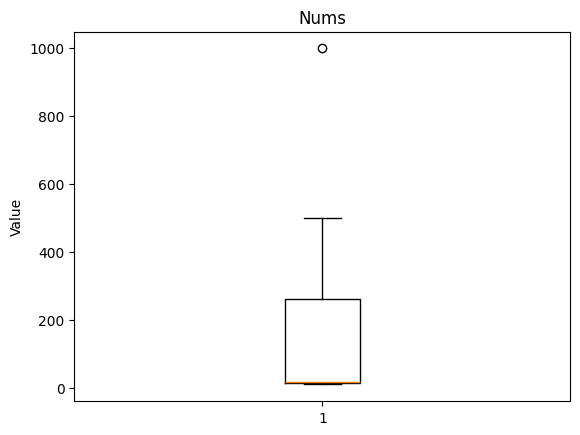

In [17]:
fig, ax = plt.subplots()
ax.boxplot(arr2)
ax.set_title("Nums")
ax.set_ylabel("Value")
plt.show()

In [23]:
x1 = q1 - 1.5 * iqr
x2 = q3 + 1.5 * iqr
outliers = arr2[(arr2 < x1) | (arr2 > x2)]
outlier_fraction = len(outliers) / len(df)
print(outlier_fraction)

0.04
